### Домашняя работа №6 — MHLA (Multi-Head Linear Attention)

**Статья:** *MHLA: Restoring Expressivity of Linear Attention via Token-Level
Multi-Head*, ICLR 2026 (код: github.com/DAGroup-PKU/MHLA).

**Эксперимент:** MHLA-ViT (`deit_tiny_pla_1d_v6_6`) против softmax-бейслайна
DeiT-Tiny той же ширины (~5.5M параметров) на PathMNIST (9 классов гистологии,
MedMNIST — данных достаточно для обучения с нуля).

In [ ]:
!pip install -q "timm==1.0.15" einops medmnist
!git clone -q https://github.com/DAGroup-PKU/MHLA.git
import sys
sys.path.insert(0, "MHLA/mhla_image_classification")

import time, random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

fatal: destination path 'MHLA' already exists and is not an empty directory.
device: cuda


In [ ]:
from types import SimpleNamespace
args = SimpleNamespace(
    data_flag="pathmnist",
    img_size=224,
    max_train=12000,
    epochs=30,
    warmup_epochs=8,
    batch_size=64,
    opt="adamw",
    lr=4e-4,
    weight_decay=0.05,
    sched="cosine",
    warmup_lr=1e-6,
    min_lr=1e-5,
    drop_path=0.05,
    smoothing=0.1,
    mixup=0.0,
    cutmix=0.0,
    aa="rand-m5-mstd0.5-inc1",
    color_jitter=0.4,
    reprob=0.1,
    model_ema_decay=0.9996,
    clip_grad=0.5,
    amp=False,
    fast_dev_run=False,
)
if args.fast_dev_run:
    args.epochs, args.warmup_epochs, args.max_train = 2, 0, 512

In [ ]:
import medmnist
from medmnist import INFO
from timm.data import create_transform
from torch.utils.data import DataLoader, Subset

info = INFO[args.data_flag]
NUM_CLASSES = len(info["label"])
CLASS_NAMES = [info["label"][str(i)] for i in range(NUM_CLASSES)]
DataClass = getattr(medmnist, info["python_class"])
MEAN, STD = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)

train_tf = create_transform(
    input_size=args.img_size, is_training=True, auto_augment=args.aa,
    re_prob=args.reprob, color_jitter=args.color_jitter,
    interpolation="bicubic", mean=MEAN, std=STD)
test_tf = create_transform(
    input_size=args.img_size, is_training=False,
    interpolation="bicubic", mean=MEAN, std=STD, crop_pct=1.0)
squeeze = lambda y: int(np.asarray(y).squeeze())

train_set = DataClass(split="train", download=True, size=64,
                      transform=train_tf, target_transform=squeeze)
test_set  = DataClass(split="test", download=True, size=64,
                      transform=test_tf, target_transform=squeeze)
if len(train_set) > args.max_train:
    idx = np.random.RandomState(SEED).choice(len(train_set), args.max_train, replace=False)
    train_set = Subset(train_set, idx.tolist())
if args.fast_dev_run:
    train_set = Subset(train_set, range(512)); test_set = Subset(test_set, range(256))

train_loader = DataLoader(train_set, args.batch_size, shuffle=True, num_workers=2,
                          pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_set, 128, shuffle=False, num_workers=2, pin_memory=True)
print(f"classes ({NUM_CLASSES}), train {len(train_set)}, test {len(test_set)}")

classes (9), train 12000, test 7180


In [ ]:
from timm.data import Mixup
mixup_fn = Mixup(mixup_alpha=args.mixup, cutmix_alpha=args.cutmix,
                 label_smoothing=args.smoothing, num_classes=NUM_CLASSES)

In [ ]:
import models.timm_registers
import timm

def build(kind):
    if kind == "mhla":
        return timm.create_model("deit_tiny_pla_1d_v6_6", pretrained=False,
                                 num_classes=NUM_CLASSES, global_pool="avg",
                                 drop_path_rate=args.drop_path,
                                 piece_size=4, transform="linear", exp_sigma=1).to(DEVICE)
    return timm.create_model("deit_tiny_patch16_224", pretrained=False,
                             num_classes=NUM_CLASSES, img_size=args.img_size,
                             drop_path_rate=args.drop_path).to(DEVICE)

n_params = lambda m: sum(p.numel() for p in m.parameters()) / 1e6
for k in ["mhla", "vit"]:
    print(f"{k:5s}: {n_params(build(k)):.2f}M параметров")

mhla : 5.60M параметров
vit  : 5.53M параметров


In [ ]:
import torch.nn as nn
from timm.optim import create_optimizer_v2
from timm.scheduler import create_scheduler_v2
from timm.utils import ModelEmaV3, NativeScaler
from timm.loss import SoftTargetCrossEntropy
from torch.amp import autocast

@torch.no_grad()
def evaluate(model, loader, preds=False):
    model.eval(); cor = tot = 0; n = 0; t0 = time.time(); ys = []; ps = []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with autocast(DEVICE, enabled=args.amp):
            out = model(x)
        p = out.argmax(1); cor += (p == y).sum().item(); tot += y.numel(); n += y.numel()
        if preds: ys += y.cpu().tolist(); ps += p.cpu().tolist()
    if DEVICE == "cuda": torch.cuda.synchronize()
    return (cor/tot, n/(time.time()-t0), ys, ps) if preds else (cor/tot, n/(time.time()-t0))

def train_model(kind):
    model = build(kind)
    optimizer = create_optimizer_v2(model, opt=args.opt, lr=args.lr,
                                    weight_decay=args.weight_decay)
    scheduler, _ = create_scheduler_v2(
        optimizer, sched=args.sched, num_epochs=args.epochs,
        warmup_epochs=args.warmup_epochs, warmup_lr=args.warmup_lr, min_lr=args.min_lr)
    use_mixup = args.mixup > 0 or args.cutmix > 0
    loss_fn = SoftTargetCrossEntropy() if use_mixup else nn.CrossEntropyLoss(label_smoothing=args.smoothing)
    loss_scaler = NativeScaler() if args.amp else None
    model_ema = ModelEmaV3(model, decay=args.model_ema_decay)
    hist = {"train_loss": [], "val_acc": [], "epoch_time": []}

    for epoch in range(args.epochs):
        model.train(); t0 = time.time(); run = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if use_mixup:
                x, y = mixup_fn(x, y)
            with autocast(DEVICE, enabled=args.amp):
                loss = loss_fn(model(x), y)
            if not torch.isfinite(loss):
                continue
            optimizer.zero_grad()
            if loss_scaler is not None:
                loss_scaler(loss, optimizer, clip_grad=args.clip_grad,
                            parameters=model.parameters())
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), args.clip_grad)
                optimizer.step()
            model_ema.update(model)
            run += loss.item()
        scheduler.step(epoch + 1)
        acc, _ = evaluate(model_ema.module, test_loader)
        hist["train_loss"].append(run/len(train_loader))
        hist["val_acc"].append(acc); hist["epoch_time"].append(time.time()-t0)
        print(f"[{kind}] ep {epoch+1:02d}/{args.epochs} | loss {hist['train_loss'][-1]:.3f} "
              f"| val acc {acc*100:.2f}% | {hist['epoch_time'][-1]:.1f}s")
    acc, thr, ys, ps = evaluate(model_ema.module, test_loader, preds=True)
    hist.update(throughput=thr, params=n_params(model), preds=(ys, ps))
    return hist

results = {}
for k in ["mhla", "vit"]:
    print(f"\n=== Обучение: {k} ===")
    results[k] = train_model(k)


=== Обучение: mhla ===
[mhla] ep 01/30 | loss 2.128 | val acc 12.90% | 110.3s
[mhla] ep 02/30 | loss 1.729 | val acc 17.94% | 107.4s
[mhla] ep 03/30 | loss 1.468 | val acc 25.45% | 107.8s
[mhla] ep 04/30 | loss 1.327 | val acc 31.06% | 106.3s
[mhla] ep 05/30 | loss 1.259 | val acc 40.65% | 106.8s
[mhla] ep 06/30 | loss 1.237 | val acc 50.22% | 108.1s
[mhla] ep 07/30 | loss 1.227 | val acc 55.97% | 107.7s
[mhla] ep 08/30 | loss 1.202 | val acc 62.53% | 106.7s
[mhla] ep 09/30 | loss 1.151 | val acc 68.80% | 106.8s
[mhla] ep 10/30 | loss 1.143 | val acc 71.35% | 108.0s
[mhla] ep 11/30 | loss 1.167 | val acc 73.59% | 107.0s
[mhla] ep 12/30 | loss 1.176 | val acc 74.65% | 106.8s
[mhla] ep 13/30 | loss 1.132 | val acc 75.28% | 106.8s
[mhla] ep 14/30 | loss 1.101 | val acc 76.06% | 108.0s
[mhla] ep 15/30 | loss 1.098 | val acc 76.87% | 106.8s
[mhla] ep 16/30 | loss 1.126 | val acc 77.65% | 107.2s
[mhla] ep 17/30 | loss 1.094 | val acc 78.19% | 106.9s
[mhla] ep 18/30 | loss 1.106 | val acc 78

In [ ]:
import pandas as pd
rows = [{"модель": lab, "параметры,M": round(results[k]["params"], 2),
         "best val acc,%": round(max(results[k]["val_acc"])*100, 2),
         "final val acc,%": round(results[k]["val_acc"][-1]*100, 2),
         "ср. эпоха,с": round(np.mean(results[k]["epoch_time"]), 1),
         "inference,img/s": round(results[k]["throughput"])}
        for k, lab in [("mhla", "MHLA-ViT"), ("vit", "DeiT-Tiny (softmax)")]]
df = pd.DataFrame(rows).set_index("модель"); df.to_csv("mhla_results.csv"); df

,"параметры,M","best val acc,%","final val acc,%","ср. эпоха,с","inference,img/s"
модель,,,,,
MHLA-ViT,5.60,82.90,82.90,107.5,417
DeiT-Tiny (softmax),5.53,85.38,85.38,71.8,410


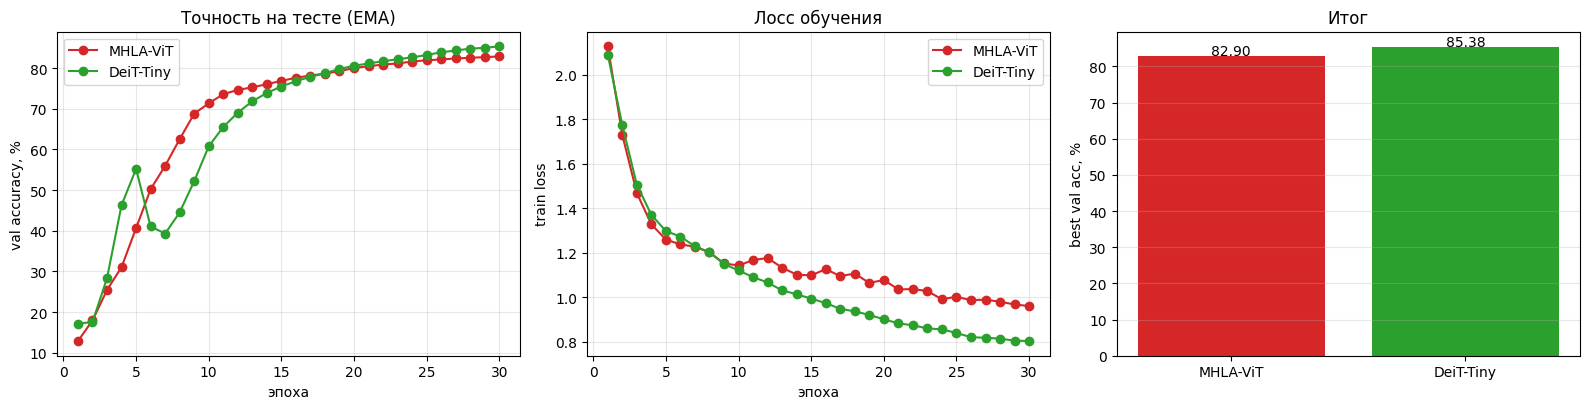

In [ ]:
import matplotlib.pyplot as plt
LAB = {"mhla": "MHLA-ViT", "vit": "DeiT-Tiny"}; C = {"mhla": "tab:red", "vit": "tab:green"}
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for k in ["mhla", "vit"]:
    ep = range(1, args.epochs+1)
    ax[0].plot(ep, [a*100 for a in results[k]["val_acc"]], "o-", label=LAB[k], color=C[k])
    ax[1].plot(ep, results[k]["train_loss"], "o-", label=LAB[k], color=C[k])
ax[0].set(xlabel="эпоха", ylabel="val accuracy, %", title="Точность на тесте (EMA)")
ax[1].set(xlabel="эпоха", ylabel="train loss", title="Лосс обучения")
for a in ax[:2]: a.grid(alpha=0.3); a.legend()
accs = [max(results[k]["val_acc"])*100 for k in ["mhla", "vit"]]
ax[2].bar([LAB[k] for k in ["mhla", "vit"]], accs, color=[C[k] for k in ["mhla", "vit"]])
for i, v in enumerate(accs): ax[2].text(i, v+0.3, f"{v:.2f}", ha="center")
ax[2].set(ylabel="best val acc, %", title="Итог"); ax[2].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("mhla_curves.png", dpi=150); plt.show()

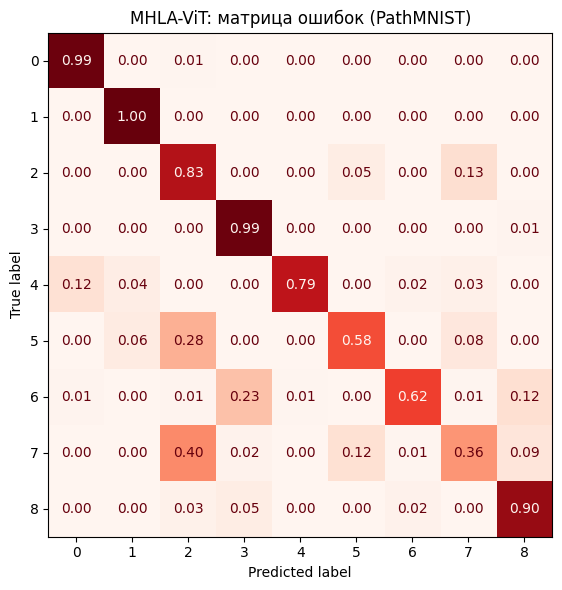

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ys, ps = results["mhla"]["preds"]
labels = sorted(set(ys) | set(ps))
cm = confusion_matrix(ys, ps, labels=labels, normalize="true")
fig, a = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=a, cmap="Reds", values_format=".2f", colorbar=False)
a.set_title("MHLA-ViT: матрица ошибок (PathMNIST)")
plt.tight_layout(); plt.savefig("mhla_confusion.png", dpi=150); plt.show()

In [ ]:
best = {k: max(results[k]["val_acc"])*100 for k in ["mhla", "vit"]}
print(f"MHLA-ViT vs DeiT-Tiny: {best['mhla']-best['vit']:+.2f} п.п.")
print(f"throughput: MHLA {results['mhla']['throughput']:.0f} img/s, "
      f"ViT {results['vit']['throughput']:.0f} img/s")
print(f"параметры: {results['mhla']['params']:.2f}M vs {results['vit']['params']:.2f}M")

MHLA-ViT vs DeiT-Tiny: -2.48 п.п.
throughput: MHLA 417 img/s, ViT 410 img/s
параметры: 5.60M vs 5.53M


### Вывод

При равном числе параметров (~5.5M) MHLA-ViT достигает 82.9% против 85.4% у softmax-DeiT — линейное внимание уступает 2.5 п.п. на короткой последовательности (196 токенов), где квадратичная сложность softmax ещё не является узким местом. Это согласуется с позиционированием метода: MHLA размен — небольшая потеря выразительности на коротком контексте в обмен на O(N)-масштабирование, окупающееся на длинных последовательностях. Дополнительно отмечена практическая особенность: наивное обучение MHLA нестабильно (fp16-переполнения в экспоненциальных feature-maps, расходимость при LR 1e-3 на малом батче); устойчивость достигнута fp32, сниженным LR (4e-4), удлинённым warmup (8 эпох) и EMA весов — т.е. линейное внимание требует более аккуратного рецепта обучения, чем softmax.

